In [35]:
# Import
import shutil
import torch
import tempfile
from pathlib import Path
from mrpro.data import KData  # Import the KData class
from mrpro.data.traj_calculators import KTrajectoryPulseq, KTrajectoryIsmrmrd
from mrpro.data.SpatialDimension import SpatialDimension
import matplotlib.pyplot as plt
import requests
import mrpro
import nibabel as nib
import numpy as np


# Local path
# 2k0
h5_2D_path1 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_7308k0_2interleaves_golden_angle_vds/meas_MID00052_FID06898_20240731_spiral_2D_256mm_7308k0_2interleaves_golden_angle_vds_with_traj.h5'
seq_2D_path1 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_7308k0_2interleaves_golden_angle_vds/20240731_spiral_2D_256mm_7308k0_2interleaves_golden_angle_vds.seq'

h5_3D_path1 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_7311k0_12_slices_2interleaves_golden_angle_3D/meas_MID00048_FID06894_20240731_spiral_interleaved_3D_256mm_7311k0_12_slices_2_with_traj.h5'
seq_3D_path1 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_7311k0_12_slices_2interleaves_golden_angle_3D/20240731_spiral_interleaved_3D_256mm_7311k0_12_slices_2interleaves_golden_angle_3D.seq'

# 4k0
h5_2D_path2 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_3656k0_4interleaves_golden_angle_vds/meas_MID00053_FID06899_20240731_spiral_2D_256mm_3656k0_4interleaves_golden_angle_vds_with_traj.h5'
seq_2D_path2 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_3656k0_4interleaves_golden_angle_vds/20240731_spiral_2D_256mm_3656k0_4interleaves_golden_angle_vds.seq'

h5_3D_path2 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_3659k0_12_slices_4interleaves_golden_angle_3D/meas_MID00047_FID06893_20240731_spiral_interleaved_3D_256mm_3659k0_12_slices_4_with_traj.h5'
seq_3D_path2 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_3659k0_12_slices_4interleaves_golden_angle_3D/20240731_spiral_interleaved_3D_256mm_3659k0_12_slices_4interleaves_golden_angle_3D.seq'

# 8k0
h5_2D_path3 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_1832k0_8interleaves_golden_angle_vds/meas_MID00054_FID06900_20240731_spiral_2D_256mm_1832k0_8interleaves_golden_angle_vds_with_traj.h5'
seq_2D_path3 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_1832k0_8interleaves_golden_angle_vds/20240731_spiral_2D_256mm_1832k0_8interleaves_golden_angle_vds.seq'

h5_3D_path3 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_1835k0_12_slices_8interleaves_golden_angle_3D/meas_MID00046_FID06892_20240731_spiral_interleaved_3D_256mm_1835k0_12_slices_8_with_traj.h5'
seq_3D_path3 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_1835k0_12_slices_8interleaves_golden_angle_3D/20240731_spiral_interleaved_3D_256mm_1835k0_12_slices_8interleaves_golden_angle_3D.seq'

# 16k0
h5_2D_path4 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_924k0_16interleaves_golden_angle_vds/meas_MID00055_FID06901_20240731_spiral_2D_256mm_924k0_16interleaves_golden_angle_vds_with_traj.h5'
seq_2D_path4 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_924k0_16interleaves_golden_angle_vds/20240731_spiral_2D_256mm_924k0_16interleaves_golden_angle_vds.seq'

h5_3D_path4 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_923k0_12_slices_16interleaves_golden_angle_3D/meas_MID00045_FID06891_20240731_spiral_interleaved_3D_256mm_923k0_12_slices_16_with_traj.h5'
seq_3D_path4 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_923k0_12_slices_16interleaves_golden_angle_3D/20240731_spiral_interleaved_3D_256mm_923k0_12_slices_16interleaves_golden_angle_3D.seq'

# 32k0
h5_2D_path5 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/meas_MID00056_FID06902_20240731_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds_with_traj.h5'
seq_2D_path5 = '/data/bouill01/PTBSequences/PTBSequences/31july/20240731_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds/20240731_spiral_2D_256mm_472k0_32interleaves_golden_angle_vds.seq'

h5_3D_path5 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_471k0_12_slices_32interleaves_golden_angle_3D/meas_MID00044_FID06890_20240731_spiral_interleaved_3D_256mm_471k0_12_slices_32_with_traj.h5'
seq_3D_path5 = '/data/bouill01/PTBSequences/PTBSequences/31july/3d_spirals/20240731_spiral_interleaved_3D_256mm_471k0_12_slices_32interleaves_golden_angle_3D/20240731_spiral_interleaved_3D_256mm_471k0_12_slices_32interleaves_golden_angle_3D.seq'

### 2K0

/tmp/ipykernel_28476/2789323672.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_28476/2789323672.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend()


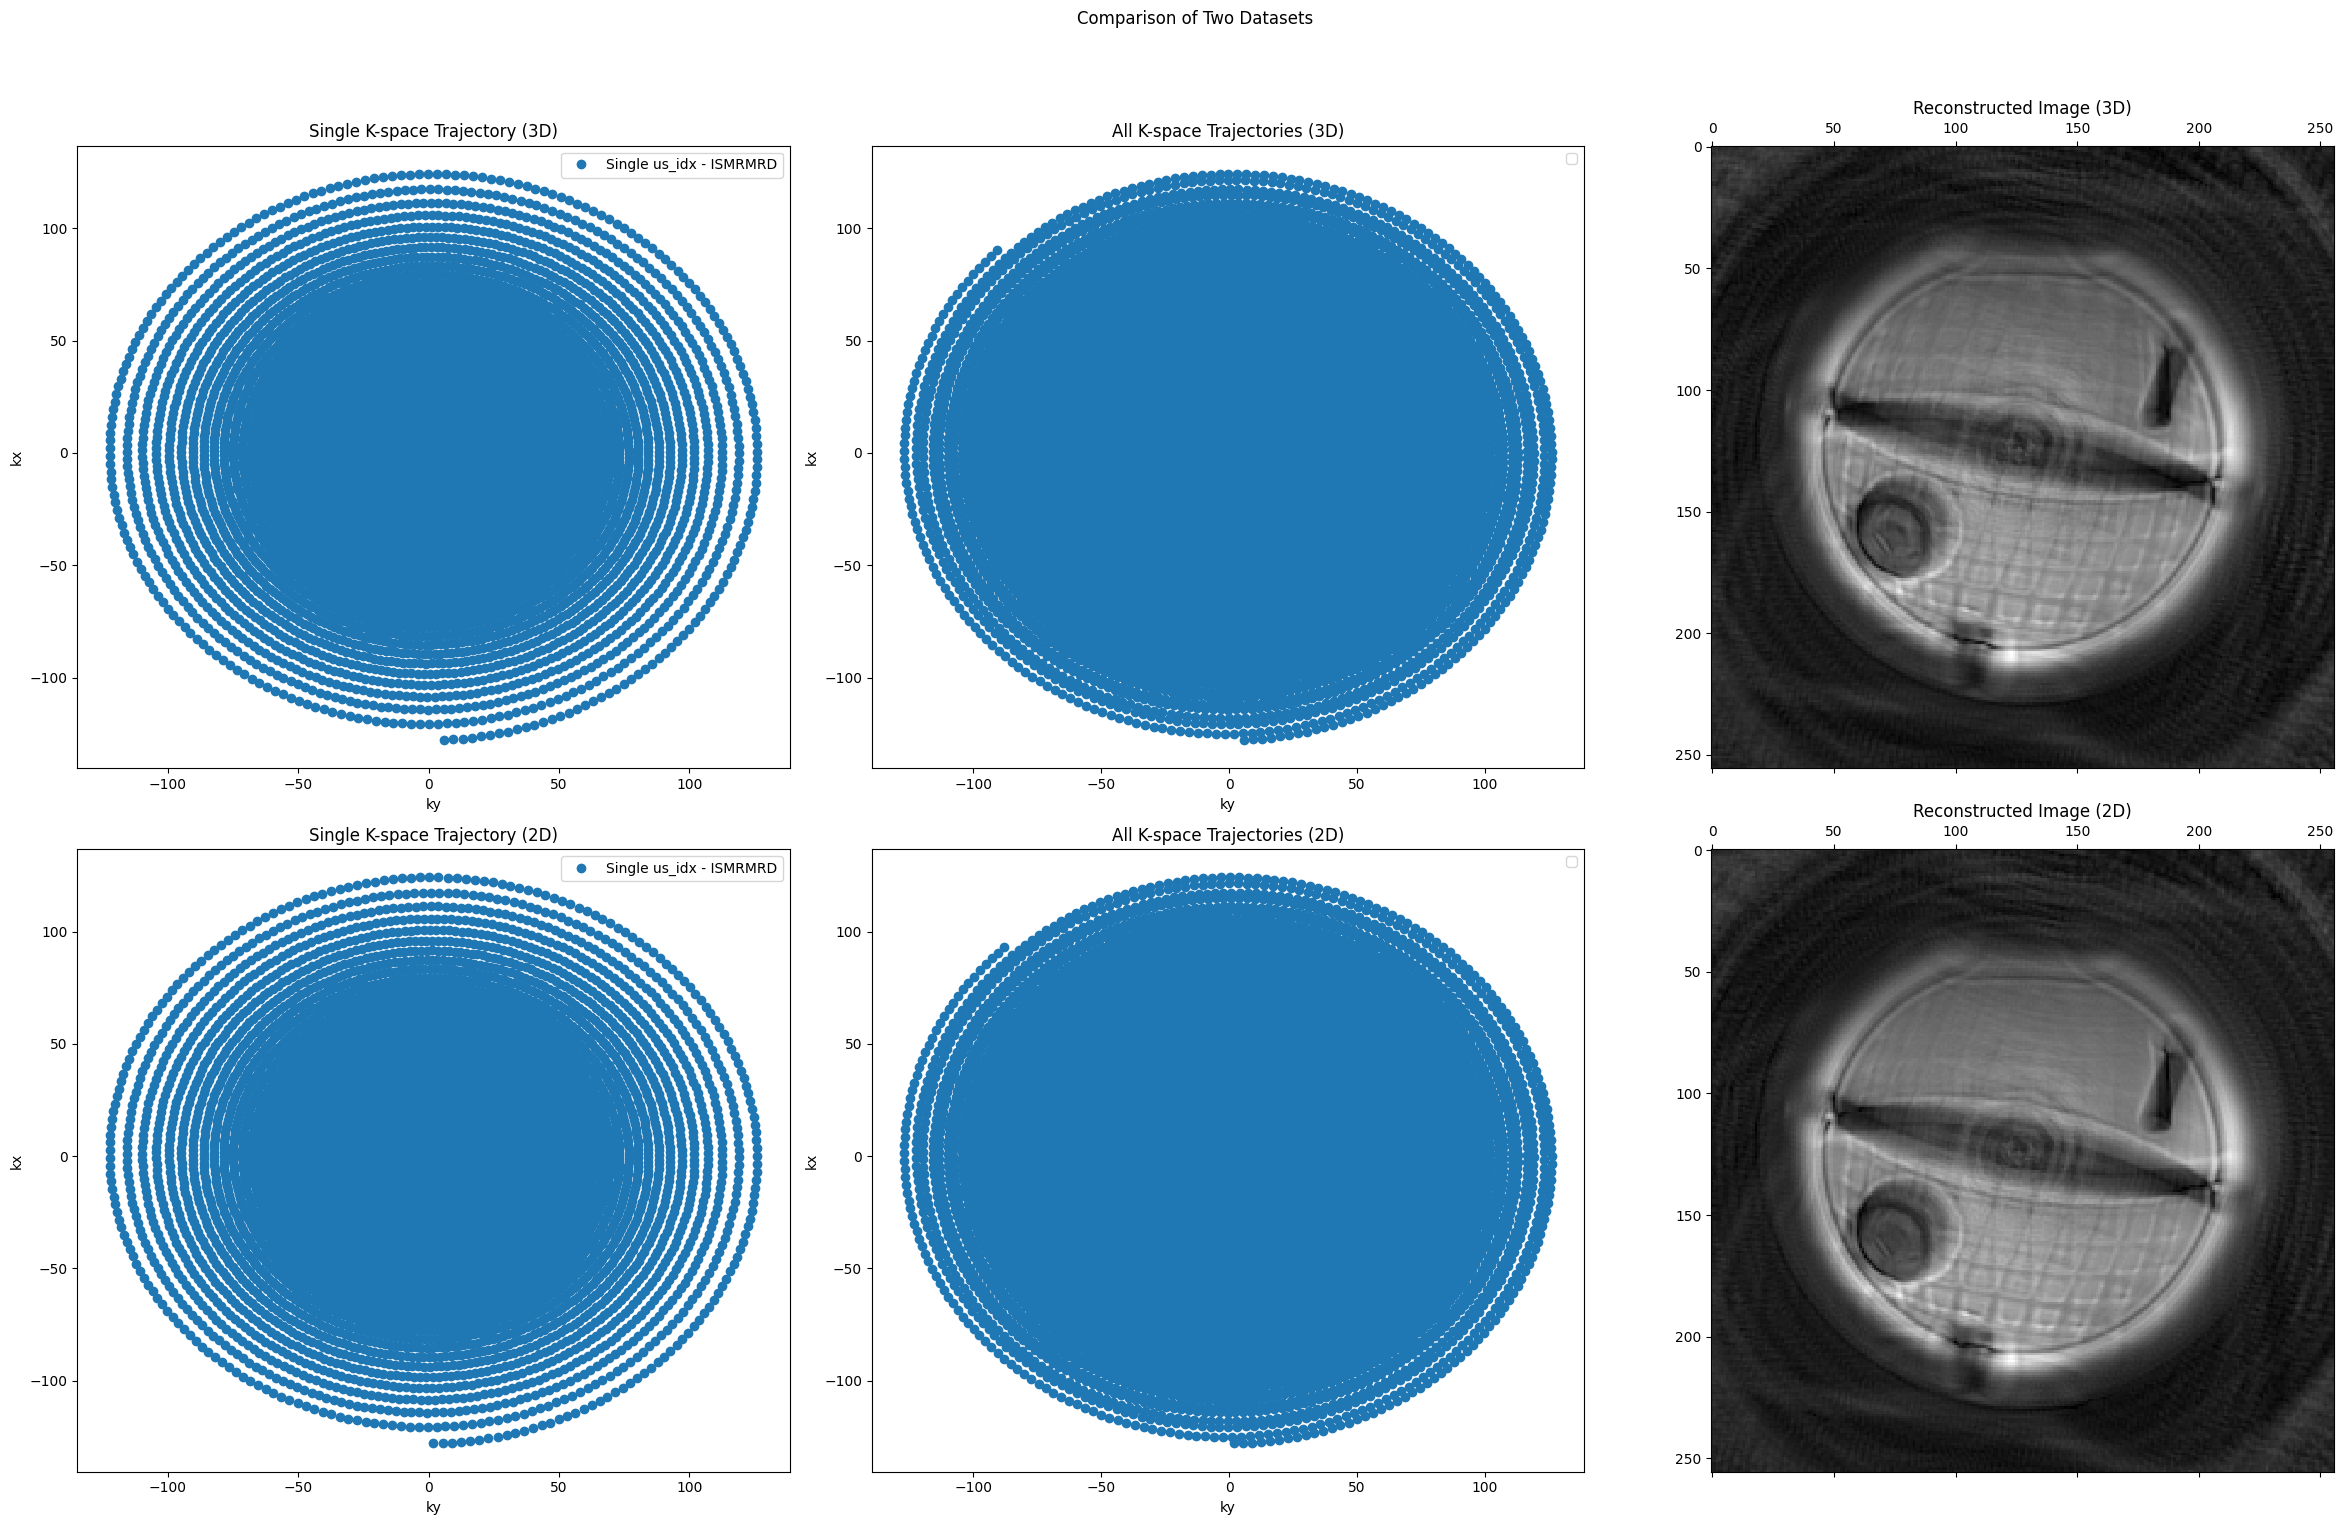

In [36]:
# Load and reconstruct the first dataset
kdata_ismrmrd_1 = KData.from_file(h5_3D_path1, KTrajectoryIsmrmrd())
kdata_ismrmrd_1.header.recon_matrix = SpatialDimension(z=12, y=256, x=256)
kdata_ismrmrd_1.header.encoding_matrix = SpatialDimension(z=12, y=256, x=256)

reconstruction_ismrmrd_1 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_1)
img_1 = reconstruction_ismrmrd_1(kdata_ismrmrd_1)
first_img_1 = img_1.rss().cpu()[0, 6, :, :]  # images, z, y, x

# Load and reconstruct the second dataset
kdata_ismrmrd_2 = KData.from_file(h5_2D_path1, KTrajectoryIsmrmrd())
reconstruction_ismrmrd_2 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_2)
img_2 = reconstruction_ismrmrd_2(kdata_ismrmrd_2)
first_img_2 = img_2.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 5, 139)[None, :]]

# Create a figure with six subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Comparison of Two Datasets')

# Plot a single k-space trajectory for the first dataset
ax1 = axes[0, 0]
single_us_idx = us_idx_values[0]
kdata_us_single_1 = kdata_ismrmrd_1.split_k1_into_other(single_us_idx, other_label='repetition')
ax1.plot(kdata_us_single_1.traj.ky.flatten(), kdata_us_single_1.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory (3D)')
ax1.legend()

# Plot k-space trajectories for all us_idx values for the first dataset
ax2 = axes[0, 1]
ax2.plot(kdata_ismrmrd_1.traj.ky.flatten(), kdata_ismrmrd_1.traj.kx.flatten(), 'o')
ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories (3D)')
ax2.legend()

# Plot the reconstructed image for the first dataset
ax3 = axes[0, 2]
ax3.matshow(first_img_1, cmap='gray')
ax3.set_title('Reconstructed Image (3D)')

# Plot a single k-space trajectory for the second dataset
ax4 = axes[1, 0]
kdata_us_single_2 = kdata_ismrmrd_2.split_k1_into_other(single_us_idx, other_label='repetition')
ax4.plot(kdata_us_single_2.traj.ky.flatten(), kdata_us_single_2.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax4.set_xlabel('ky')
ax4.set_ylabel('kx')
ax4.set_title('Single K-space Trajectory (2D)')
ax4.legend()

# Plot k-space trajectories for all us_idx values for the second dataset
ax5 = axes[1, 1]
ax5.plot(kdata_ismrmrd_2.traj.ky.flatten(), kdata_ismrmrd_2.traj.kx.flatten(), 'o')
ax5.set_xlabel('ky')
ax5.set_ylabel('kx')
ax5.set_title('All K-space Trajectories (2D)')
ax5.legend()

# Plot the reconstructed image for the second dataset
ax6 = axes[1, 2]
ax6.matshow(first_img_2, cmap='gray')
ax6.set_title('Reconstructed Image (2D)')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


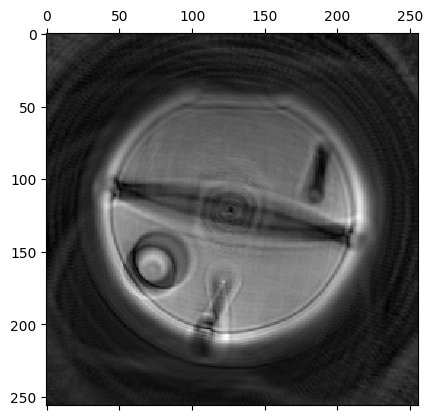

In [37]:
first_img_1 = img_1.rss().cpu()[0, 7, :, :]  
plt.matshow(first_img_1, cmap='gray')
plt.show()

### 4K0

/tmp/ipykernel_28476/1983016960.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_28476/1983016960.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend()


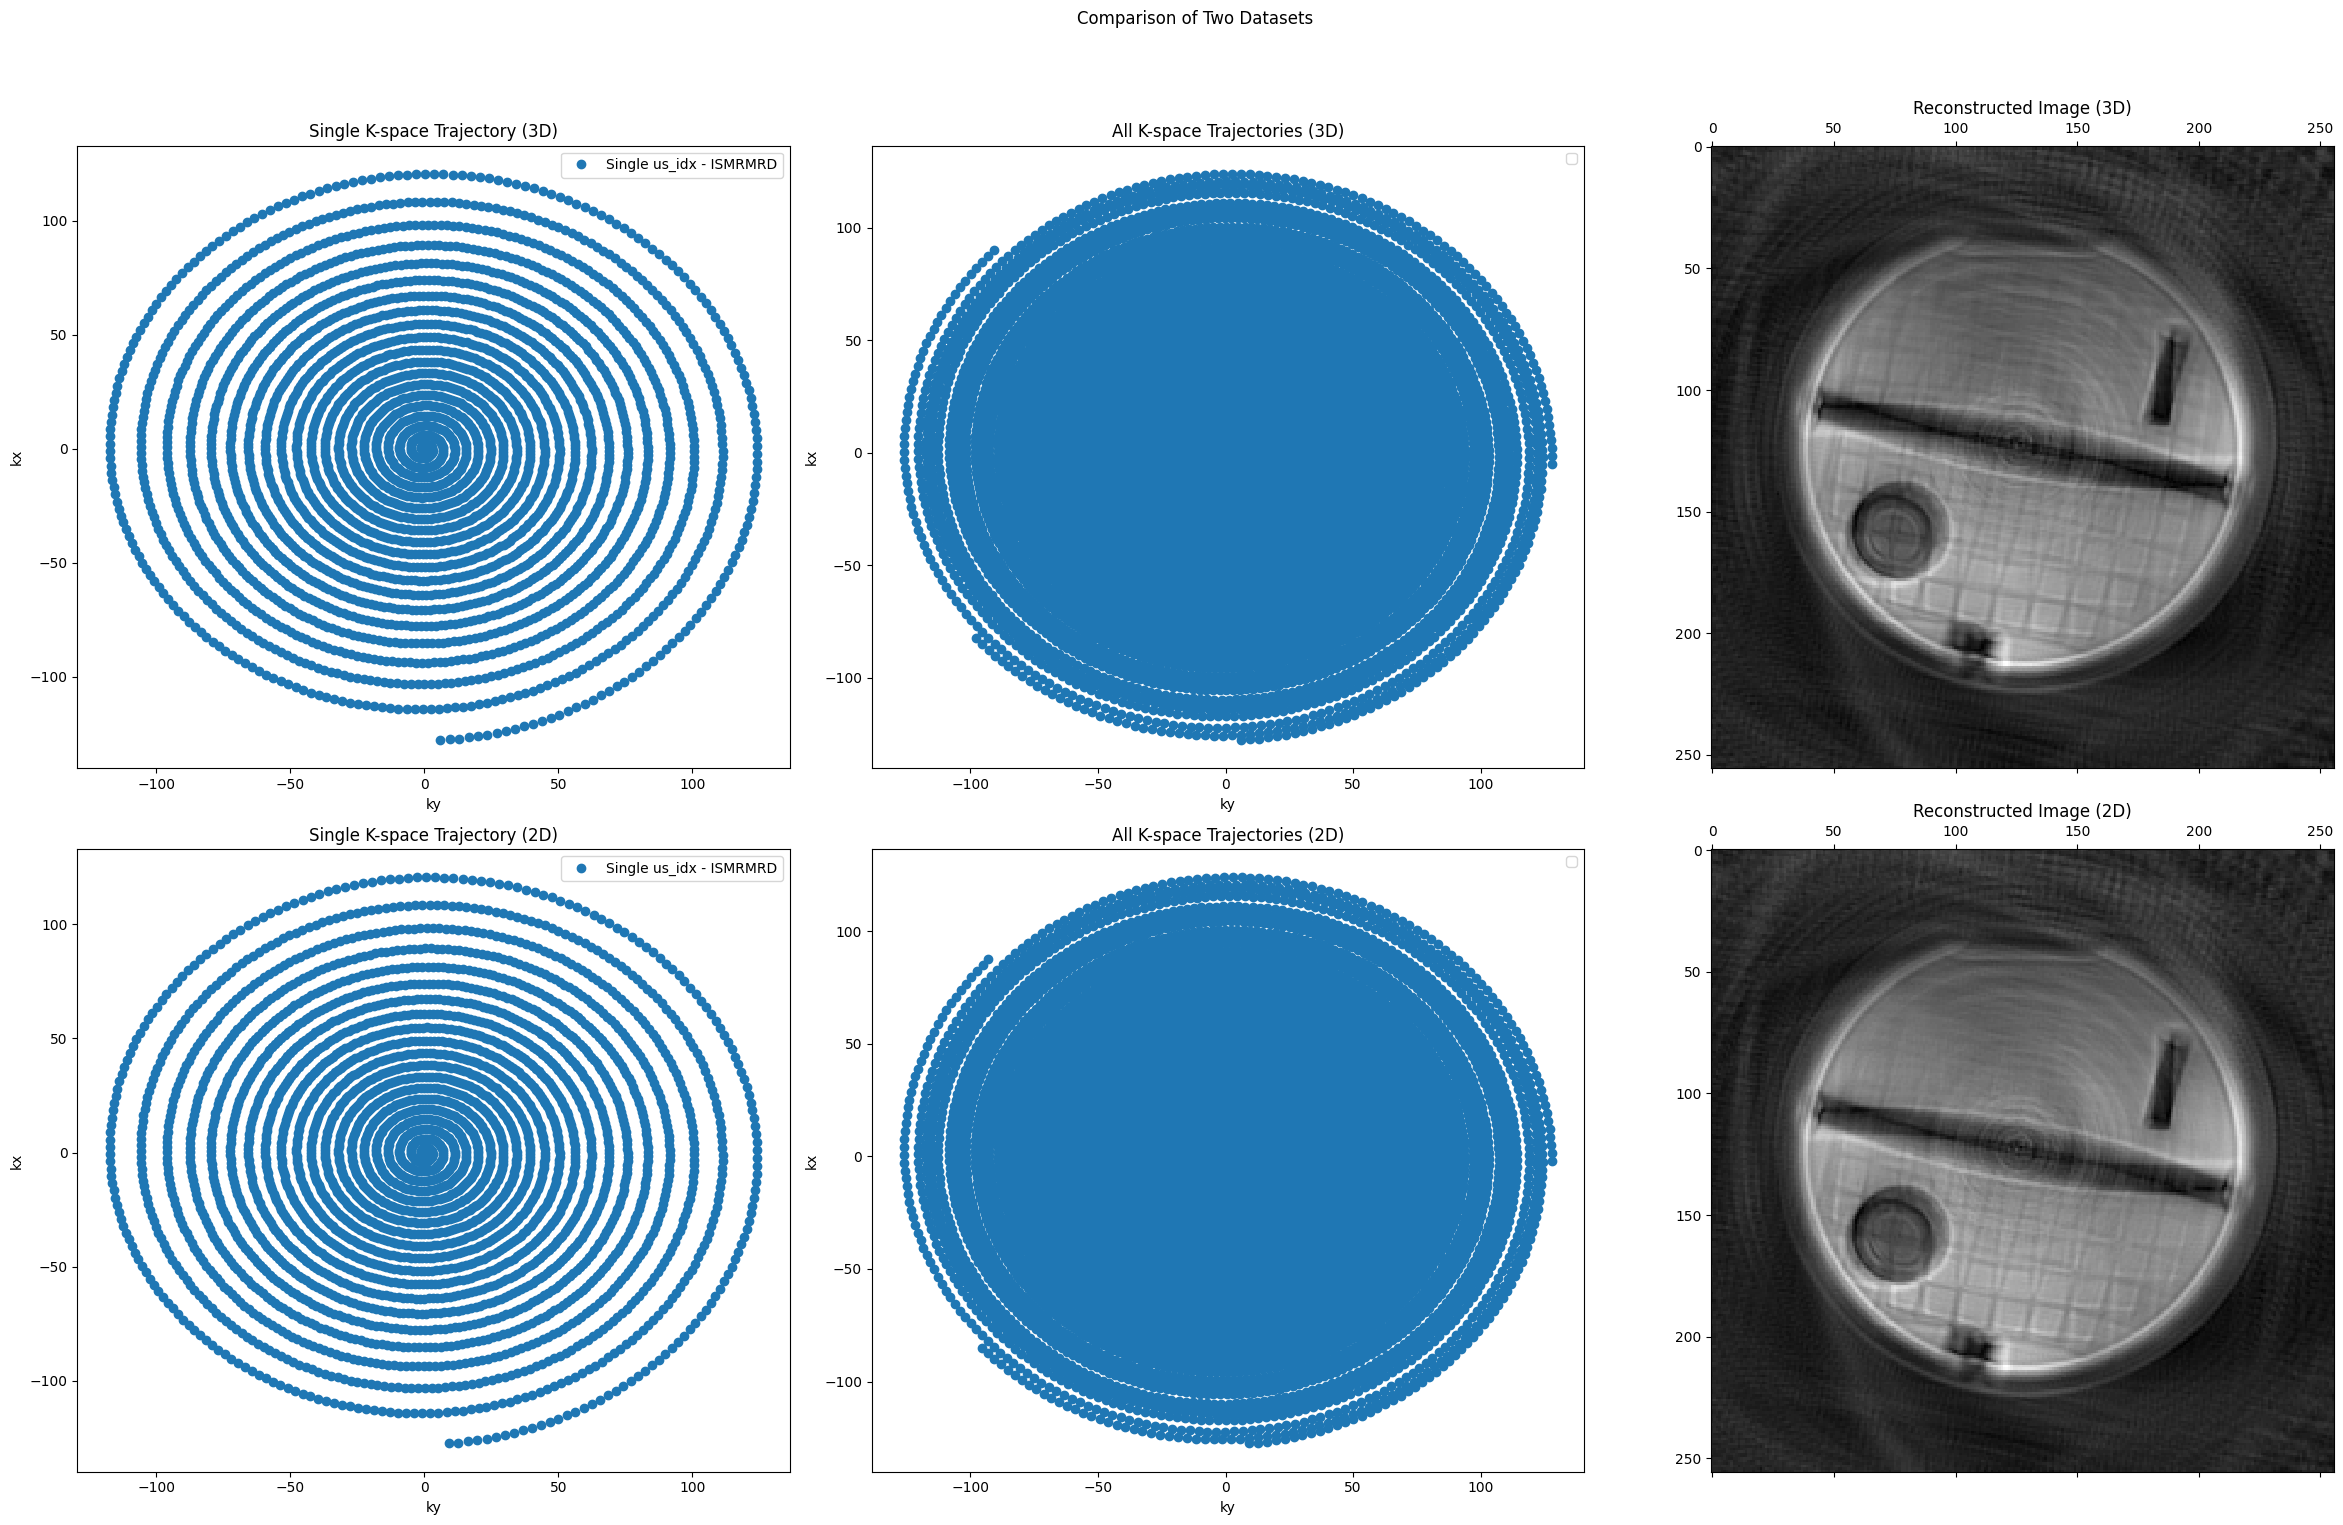

In [38]:
# Load and reconstruct the first dataset
kdata_ismrmrd_1 = KData.from_file(h5_3D_path2, KTrajectoryIsmrmrd())
kdata_ismrmrd_1.header.recon_matrix = SpatialDimension(z=12, y=256, x=256)
kdata_ismrmrd_1.header.encoding_matrix = SpatialDimension(z=12, y=256, x=256)

reconstruction_ismrmrd_1 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_1)
img_1 = reconstruction_ismrmrd_1(kdata_ismrmrd_1)
first_img_1 = img_1.rss().cpu()[0, 6, :, :]  # images, z, y, x

# Load and reconstruct the second dataset
kdata_ismrmrd_2 = KData.from_file(h5_2D_path2, KTrajectoryIsmrmrd())
reconstruction_ismrmrd_2 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_2)
img_2 = reconstruction_ismrmrd_2(kdata_ismrmrd_2)
first_img_2 = img_2.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 5, 139)[None, :]]

# Create a figure with six subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Comparison of Two Datasets')

# Plot a single k-space trajectory for the first dataset
ax1 = axes[0, 0]
single_us_idx = us_idx_values[0]
kdata_us_single_1 = kdata_ismrmrd_1.split_k1_into_other(single_us_idx, other_label='repetition')
ax1.plot(kdata_us_single_1.traj.ky.flatten(), kdata_us_single_1.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory (3D)')
ax1.legend()

# Plot k-space trajectories for all us_idx values for the first dataset
ax2 = axes[0, 1]
ax2.plot(kdata_ismrmrd_1.traj.ky.flatten(), kdata_ismrmrd_1.traj.kx.flatten(), 'o')
ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories (3D)')
ax2.legend()

# Plot the reconstructed image for the first dataset
ax3 = axes[0, 2]
ax3.matshow(first_img_1, cmap='gray')
ax3.set_title('Reconstructed Image (3D)')

# Plot a single k-space trajectory for the second dataset
ax4 = axes[1, 0]
kdata_us_single_2 = kdata_ismrmrd_2.split_k1_into_other(single_us_idx, other_label='repetition')
ax4.plot(kdata_us_single_2.traj.ky.flatten(), kdata_us_single_2.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax4.set_xlabel('ky')
ax4.set_ylabel('kx')
ax4.set_title('Single K-space Trajectory (2D)')
ax4.legend()

# Plot k-space trajectories for all us_idx values for the second dataset
ax5 = axes[1, 1]
ax5.plot(kdata_ismrmrd_2.traj.ky.flatten(), kdata_ismrmrd_2.traj.kx.flatten(), 'o')
ax5.set_xlabel('ky')
ax5.set_ylabel('kx')
ax5.set_title('All K-space Trajectories (2D)')
ax5.legend()

# Plot the reconstructed image for the second dataset
ax6 = axes[1, 2]
ax6.matshow(first_img_2, cmap='gray')
ax6.set_title('Reconstructed Image (2D)')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 8K0

/tmp/ipykernel_28476/1404975398.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_28476/1404975398.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend()


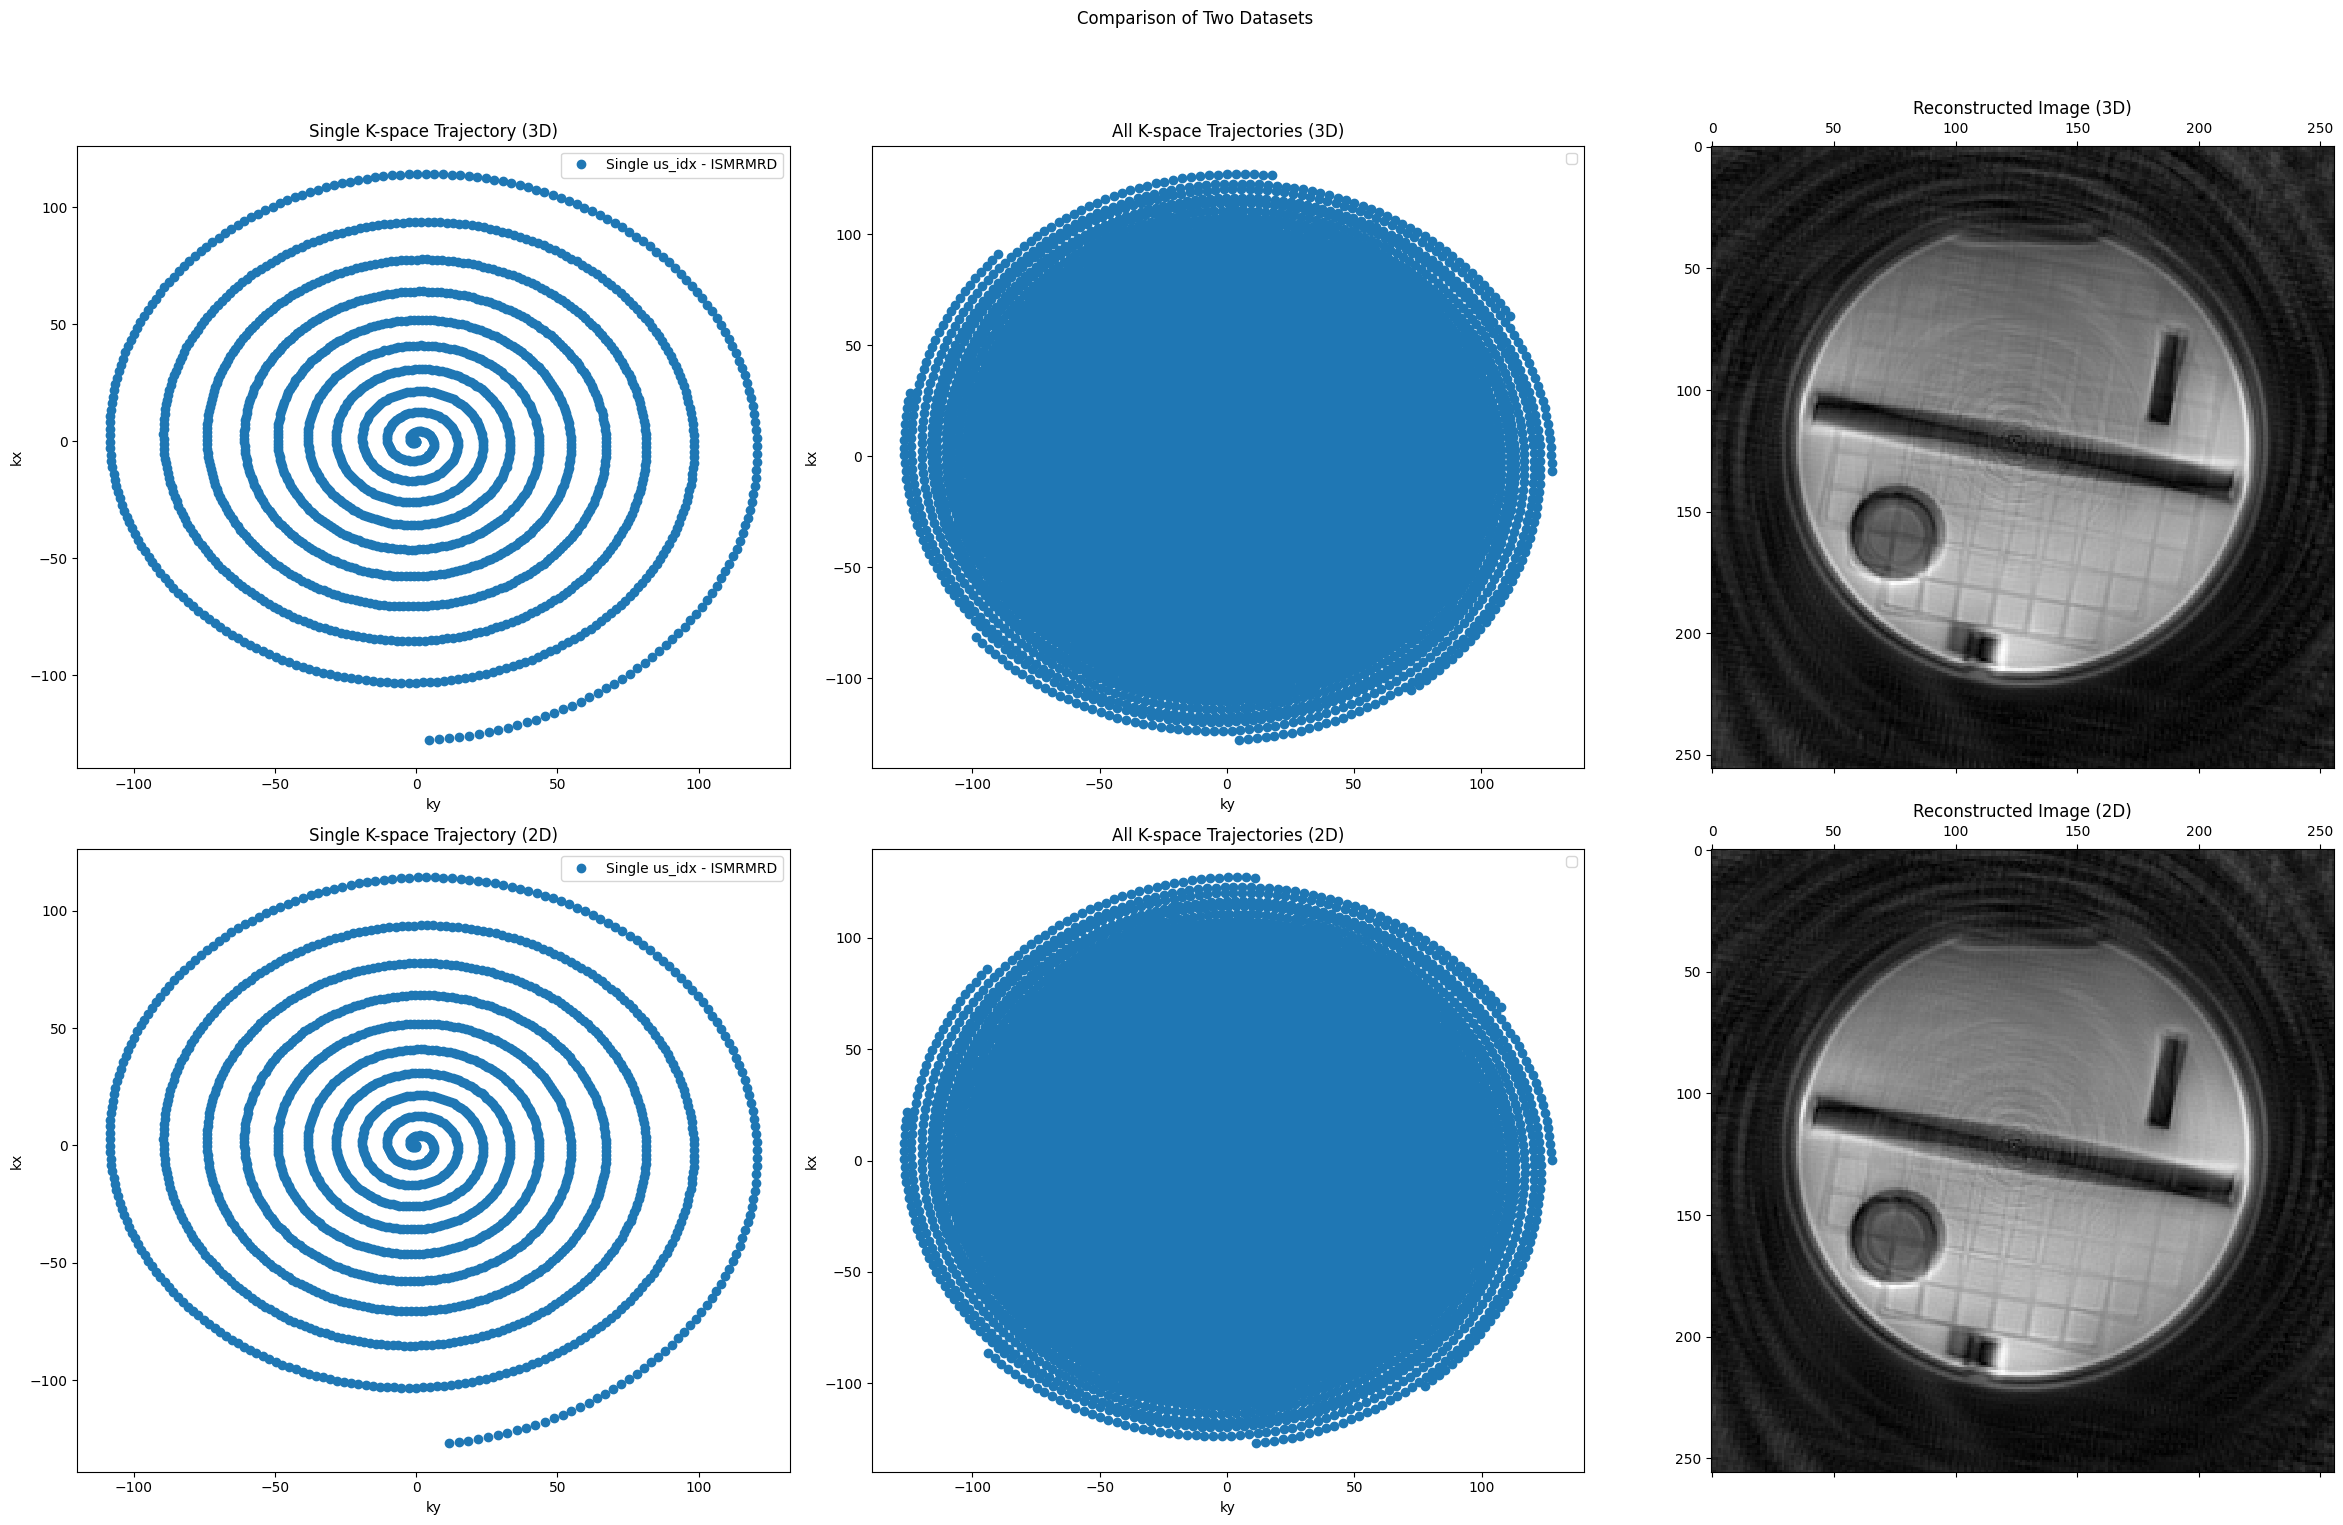

In [39]:
# Load and reconstruct the first dataset
kdata_ismrmrd_1 = KData.from_file(h5_3D_path3, KTrajectoryIsmrmrd())
kdata_ismrmrd_1.header.recon_matrix = SpatialDimension(z=12, y=256, x=256)
kdata_ismrmrd_1.header.encoding_matrix = SpatialDimension(z=12, y=256, x=256)

reconstruction_ismrmrd_1 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_1)
img_1 = reconstruction_ismrmrd_1(kdata_ismrmrd_1)
first_img_1 = img_1.rss().cpu()[0, 6, :, :]  # images, z, y, x

# Load and reconstruct the second dataset
kdata_ismrmrd_2 = KData.from_file(h5_2D_path3, KTrajectoryIsmrmrd())
reconstruction_ismrmrd_2 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_2)
img_2 = reconstruction_ismrmrd_2(kdata_ismrmrd_2)
first_img_2 = img_2.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 5, 139)[None, :]]

# Create a figure with six subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Comparison of Two Datasets')

# Plot a single k-space trajectory for the first dataset
ax1 = axes[0, 0]
single_us_idx = us_idx_values[0]
kdata_us_single_1 = kdata_ismrmrd_1.split_k1_into_other(single_us_idx, other_label='repetition')
ax1.plot(kdata_us_single_1.traj.ky.flatten(), kdata_us_single_1.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory (3D)')
ax1.legend()

# Plot k-space trajectories for all us_idx values for the first dataset
ax2 = axes[0, 1]
ax2.plot(kdata_ismrmrd_1.traj.ky.flatten(), kdata_ismrmrd_1.traj.kx.flatten(), 'o')
ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories (3D)')
ax2.legend()

# Plot the reconstructed image for the first dataset
ax3 = axes[0, 2]
ax3.matshow(first_img_1, cmap='gray')
ax3.set_title('Reconstructed Image (3D)')

# Plot a single k-space trajectory for the second dataset
ax4 = axes[1, 0]
kdata_us_single_2 = kdata_ismrmrd_2.split_k1_into_other(single_us_idx, other_label='repetition')
ax4.plot(kdata_us_single_2.traj.ky.flatten(), kdata_us_single_2.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax4.set_xlabel('ky')
ax4.set_ylabel('kx')
ax4.set_title('Single K-space Trajectory (2D)')
ax4.legend()

# Plot k-space trajectories for all us_idx values for the second dataset
ax5 = axes[1, 1]
ax5.plot(kdata_ismrmrd_2.traj.ky.flatten(), kdata_ismrmrd_2.traj.kx.flatten(), 'o')
ax5.set_xlabel('ky')
ax5.set_ylabel('kx')
ax5.set_title('All K-space Trajectories (2D)')
ax5.legend()

# Plot the reconstructed image for the second dataset
ax6 = axes[1, 2]
ax6.matshow(first_img_2, cmap='gray')
ax6.set_title('Reconstructed Image (2D)')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 16K0

/tmp/ipykernel_28476/1915061431.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_28476/1915061431.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend()


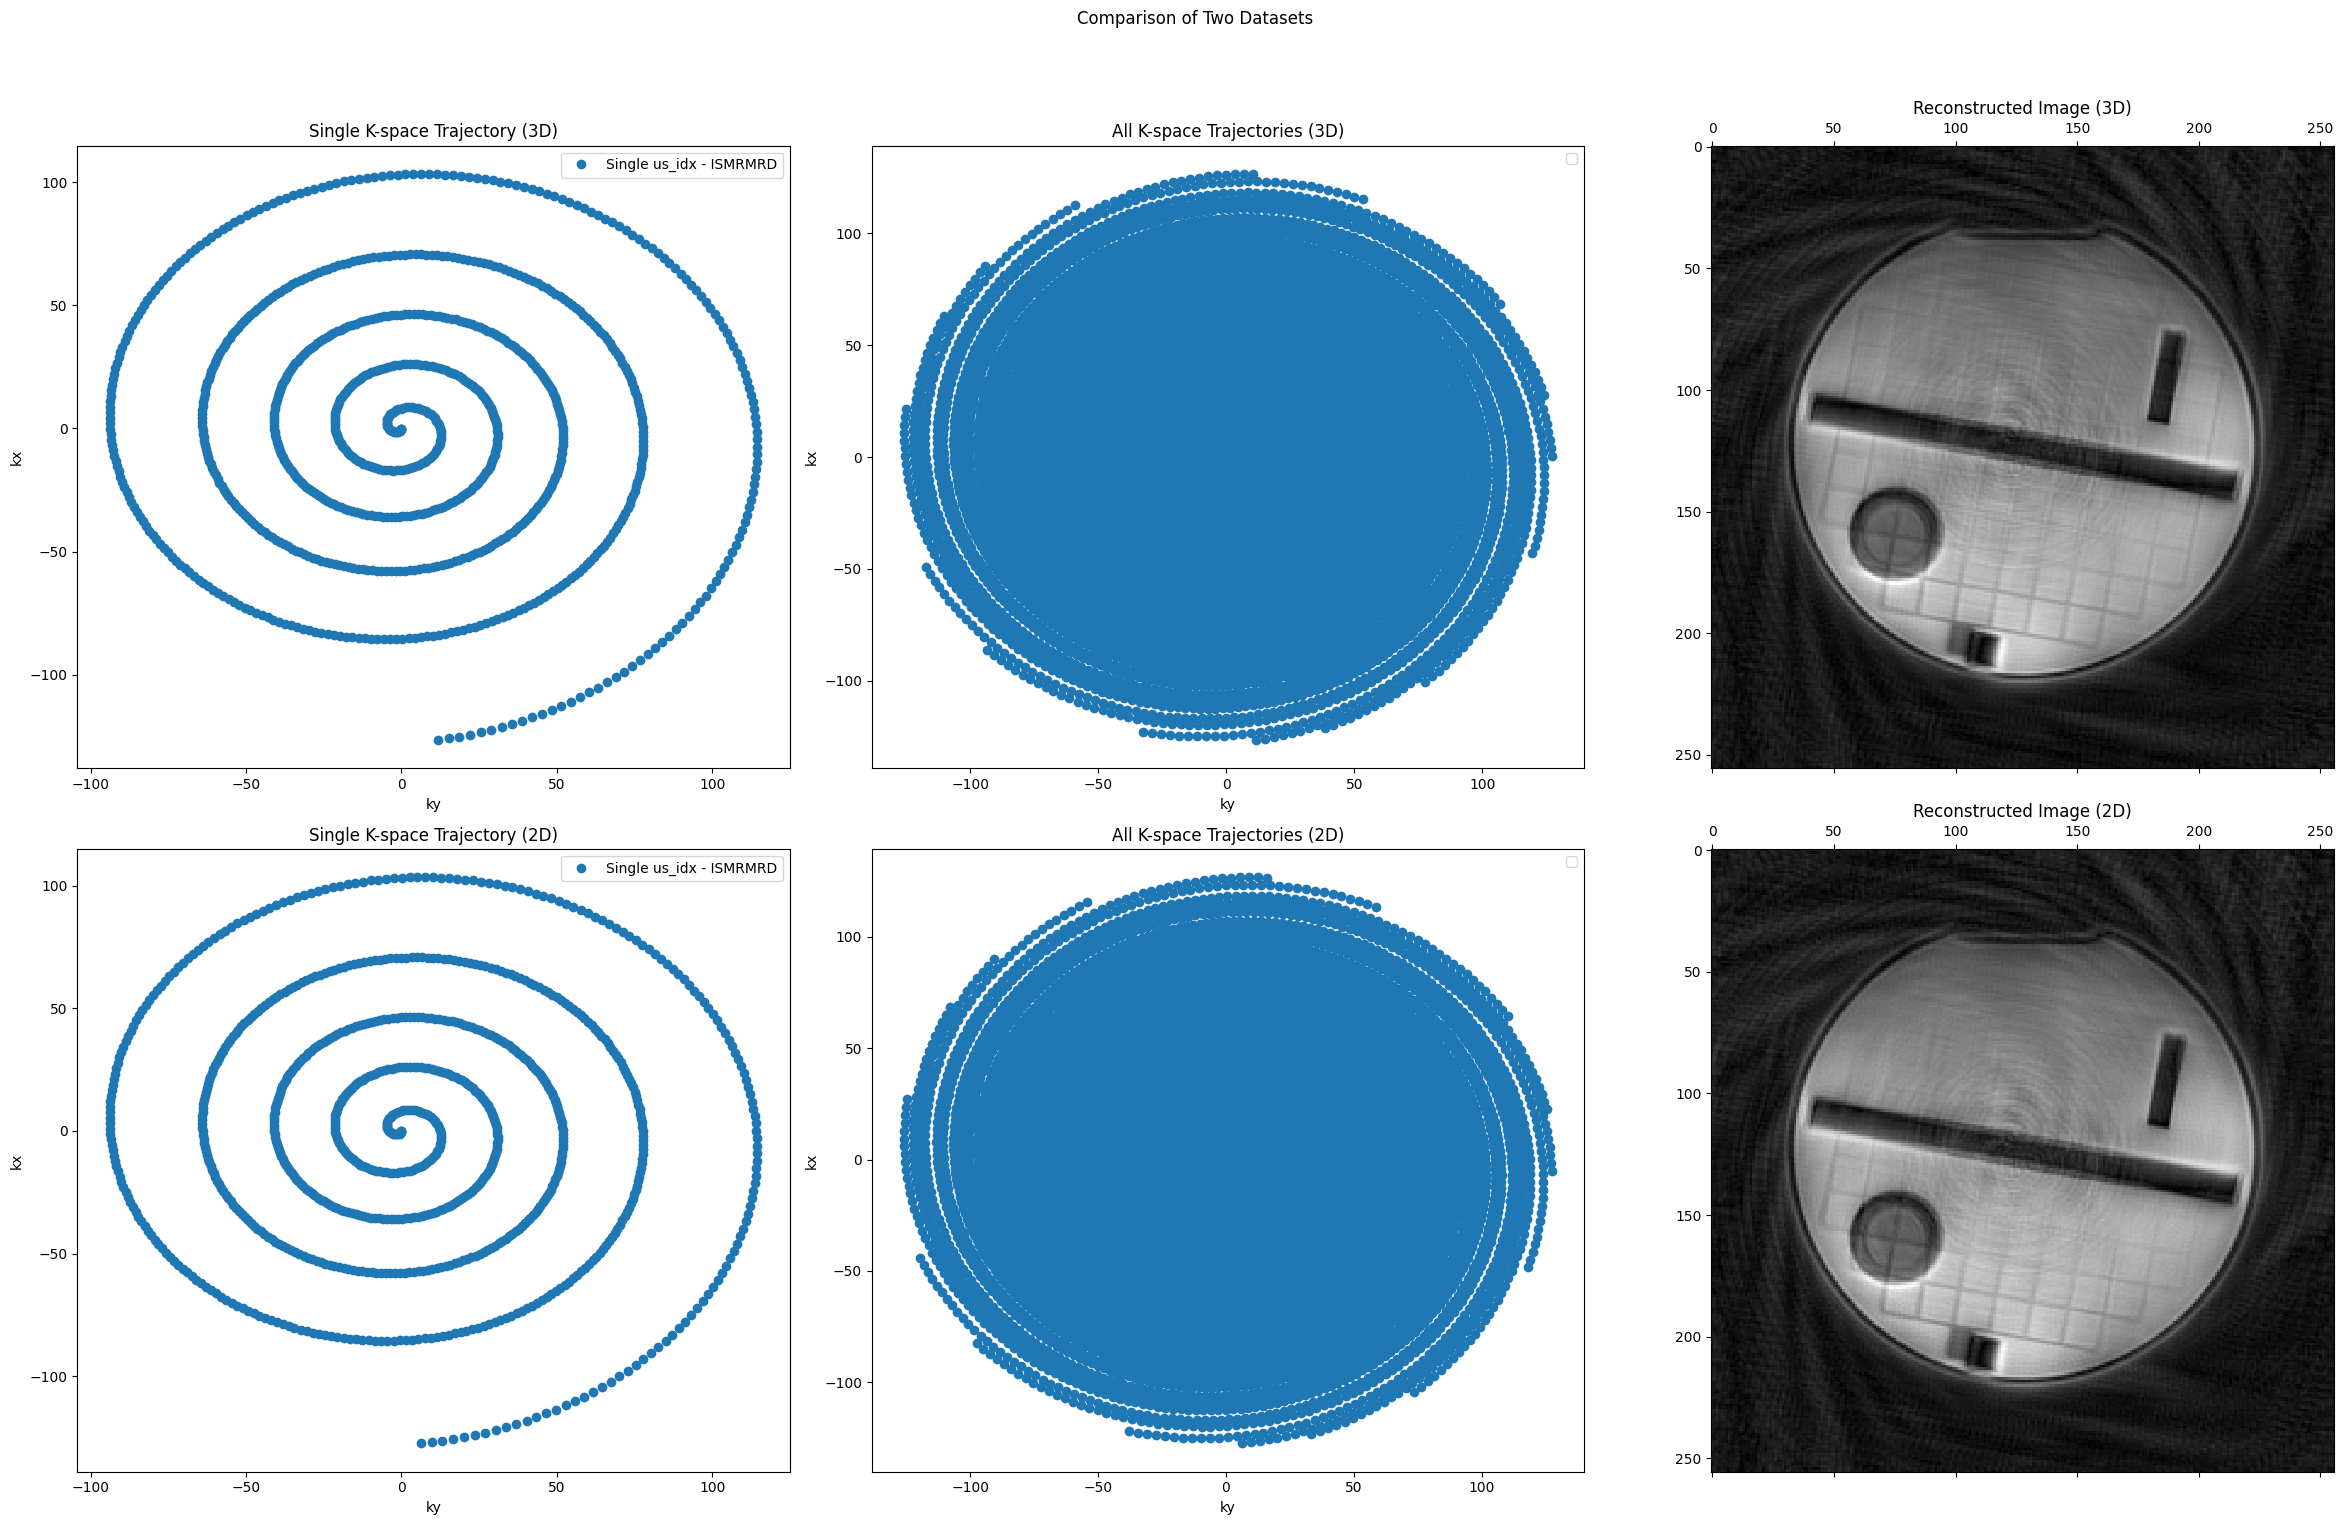

In [40]:
# Load and reconstruct the first dataset
kdata_ismrmrd_1 = KData.from_file(h5_3D_path4, KTrajectoryIsmrmrd())
kdata_ismrmrd_1.header.recon_matrix = SpatialDimension(z=12, y=256, x=256)
kdata_ismrmrd_1.header.encoding_matrix = SpatialDimension(z=12, y=256, x=256)

reconstruction_ismrmrd_1 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_1)
img_1 = reconstruction_ismrmrd_1(kdata_ismrmrd_1)
first_img_1 = img_1.rss().cpu()[0, 6, :, :]  # images, z, y, x

# Load and reconstruct the second dataset
kdata_ismrmrd_2 = KData.from_file(h5_2D_path4, KTrajectoryIsmrmrd())
reconstruction_ismrmrd_2 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_2)
img_2 = reconstruction_ismrmrd_2(kdata_ismrmrd_2)
first_img_2 = img_2.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 5, 139)[None, :]]

# Create a figure with six subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Comparison of Two Datasets')

# Plot a single k-space trajectory for the first dataset
ax1 = axes[0, 0]
single_us_idx = us_idx_values[0]
kdata_us_single_1 = kdata_ismrmrd_1.split_k1_into_other(single_us_idx, other_label='repetition')
ax1.plot(kdata_us_single_1.traj.ky.flatten(), kdata_us_single_1.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory (3D)')
ax1.legend()

# Plot k-space trajectories for all us_idx values for the first dataset
ax2 = axes[0, 1]
ax2.plot(kdata_ismrmrd_1.traj.ky.flatten(), kdata_ismrmrd_1.traj.kx.flatten(), 'o')
ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories (3D)')
ax2.legend()

# Plot the reconstructed image for the first dataset
ax3 = axes[0, 2]
ax3.matshow(first_img_1, cmap='gray')
ax3.set_title('Reconstructed Image (3D)')

# Plot a single k-space trajectory for the second dataset
ax4 = axes[1, 0]
kdata_us_single_2 = kdata_ismrmrd_2.split_k1_into_other(single_us_idx, other_label='repetition')
ax4.plot(kdata_us_single_2.traj.ky.flatten(), kdata_us_single_2.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax4.set_xlabel('ky')
ax4.set_ylabel('kx')
ax4.set_title('Single K-space Trajectory (2D)')
ax4.legend()

# Plot k-space trajectories for all us_idx values for the second dataset
ax5 = axes[1, 1]
ax5.plot(kdata_ismrmrd_2.traj.ky.flatten(), kdata_ismrmrd_2.traj.kx.flatten(), 'o')
ax5.set_xlabel('ky')
ax5.set_ylabel('kx')
ax5.set_title('All K-space Trajectories (2D)')
ax5.legend()

# Plot the reconstructed image for the second dataset
ax6 = axes[1, 2]
ax6.matshow(first_img_2, cmap='gray')
ax6.set_title('Reconstructed Image (2D)')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 32K0

/tmp/ipykernel_28476/2566235752.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
/tmp/ipykernel_28476/2566235752.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend()


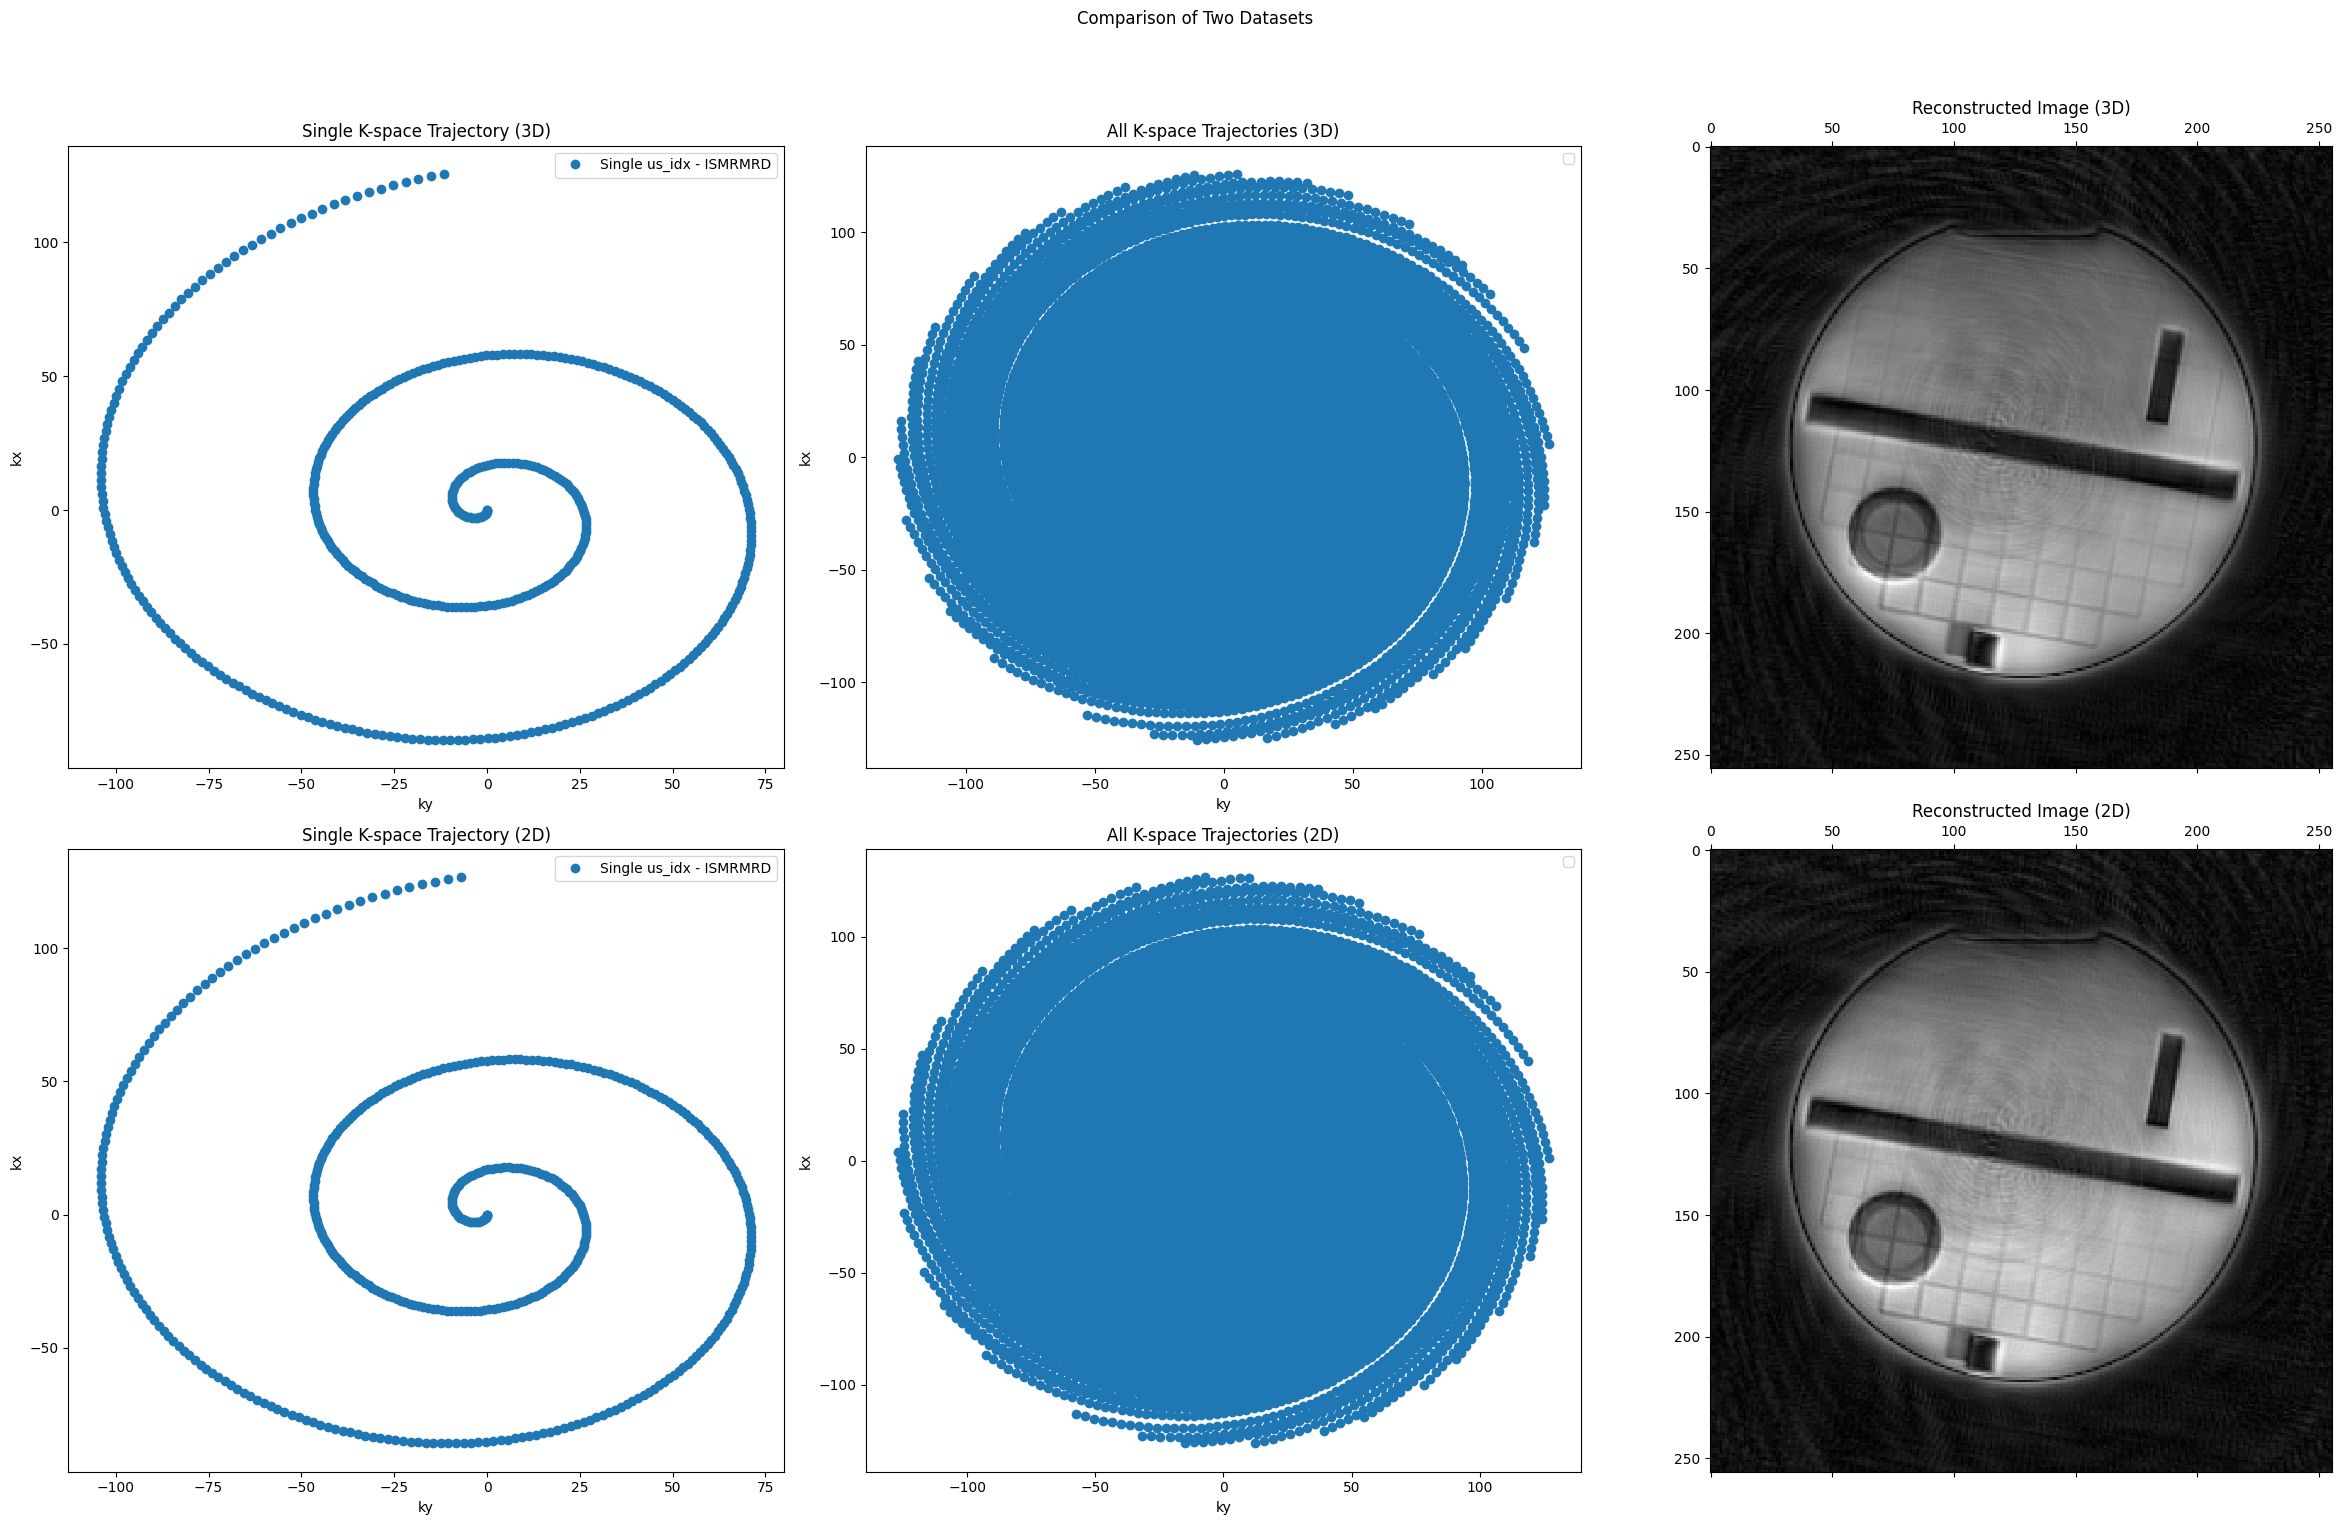

In [41]:
# Load and reconstruct the first dataset
kdata_ismrmrd_1 = KData.from_file(h5_3D_path5, KTrajectoryIsmrmrd())
kdata_ismrmrd_1.header.recon_matrix = SpatialDimension(z=12, y=256, x=256)
kdata_ismrmrd_1.header.encoding_matrix = SpatialDimension(z=12, y=256, x=256)

reconstruction_ismrmrd_1 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_1)
img_1 = reconstruction_ismrmrd_1(kdata_ismrmrd_1)
first_img_1 = img_1.rss().cpu()[0, 6, :, :]  # images, z, y, x

# Load and reconstruct the second dataset
kdata_ismrmrd_2 = KData.from_file(h5_2D_path5, KTrajectoryIsmrmrd())
reconstruction_ismrmrd_2 = mrpro.algorithms.reconstruction.DirectReconstruction.from_kdata(kdata_ismrmrd_2)
img_2 = reconstruction_ismrmrd_2(kdata_ismrmrd_2)
first_img_2 = img_2.rss().cpu()[0, 0, :, :]  # images, z, y, x

# Define values to compare for us_idx
us_idx_values = [torch.arange(0, 5, 139)[None, :]]

# Create a figure with six subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
fig.suptitle('Comparison of Two Datasets')

# Plot a single k-space trajectory for the first dataset
ax1 = axes[0, 0]
single_us_idx = us_idx_values[0]
kdata_us_single_1 = kdata_ismrmrd_1.split_k1_into_other(single_us_idx, other_label='repetition')
ax1.plot(kdata_us_single_1.traj.ky.flatten(), kdata_us_single_1.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax1.set_xlabel('ky')
ax1.set_ylabel('kx')
ax1.set_title('Single K-space Trajectory (3D)')
ax1.legend()

# Plot k-space trajectories for all us_idx values for the first dataset
ax2 = axes[0, 1]
ax2.plot(kdata_ismrmrd_1.traj.ky.flatten(), kdata_ismrmrd_1.traj.kx.flatten(), 'o')
ax2.set_xlabel('ky')
ax2.set_ylabel('kx')
ax2.set_title('All K-space Trajectories (3D)')
ax2.legend()

# Plot the reconstructed image for the first dataset
ax3 = axes[0, 2]
ax3.matshow(first_img_1, cmap='gray')
ax3.set_title('Reconstructed Image (3D)')

# Plot a single k-space trajectory for the second dataset
ax4 = axes[1, 0]
kdata_us_single_2 = kdata_ismrmrd_2.split_k1_into_other(single_us_idx, other_label='repetition')
ax4.plot(kdata_us_single_2.traj.ky.flatten(), kdata_us_single_2.traj.kx.flatten(), 'o', label='Single us_idx - ISMRMRD')
ax4.set_xlabel('ky')
ax4.set_ylabel('kx')
ax4.set_title('Single K-space Trajectory (2D)')
ax4.legend()

# Plot k-space trajectories for all us_idx values for the second dataset
ax5 = axes[1, 1]
ax5.plot(kdata_ismrmrd_2.traj.ky.flatten(), kdata_ismrmrd_2.traj.kx.flatten(), 'o')
ax5.set_xlabel('ky')
ax5.set_ylabel('kx')
ax5.set_title('All K-space Trajectories (2D)')
ax5.legend()

# Plot the reconstructed image for the second dataset
ax6 = axes[1, 2]
ax6.matshow(first_img_2, cmap='gray')
ax6.set_title('Reconstructed Image (2D)')

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
